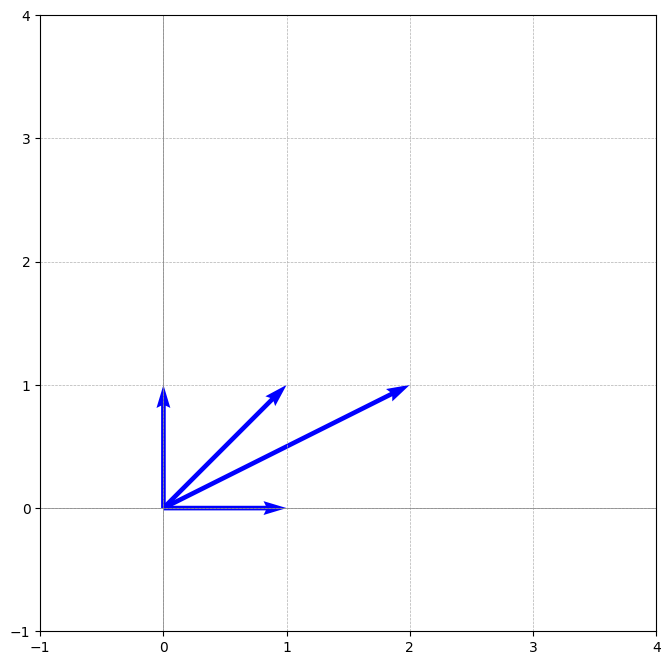

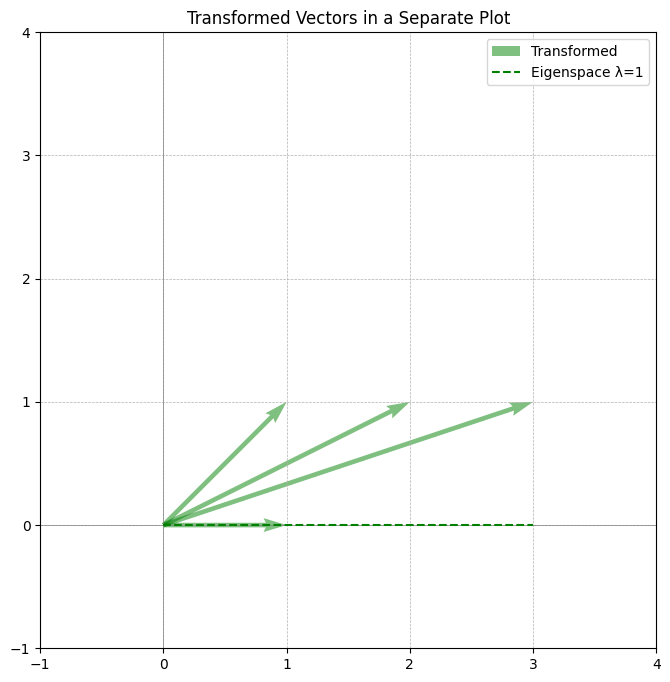

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Define the matrix A
A = np.array([[1, 1],
              [0, 1]])

# Define a set of vectors to visualize the transformation
vectors = np.array([[1, 0], [0, 1], [1, 1], [2, 1]]).T  # Each column is a vector

# Apply the transformation
transformed_vectors = A @ vectors

# Plot setup
fig, ax = plt.subplots(figsize=(8, 8))
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 4)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', linewidth=0.5)

# Plot original vectors
for i in range(vectors.shape[1]):
    ax.quiver(0, 0, vectors[0, i], vectors[1, i], angles='xy', scale_units='xy', scale=1, color='blue', label='Original' if i == 0 else "")

# Create a new figure and axis for the different plot
fig2, ax2 = plt.subplots(figsize=(8, 8))
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.axvline(0, color='gray', linewidth=0.5)
ax2.set_xlim(-1, 4)
ax2.set_ylim(-1, 4)
ax2.set_aspect('equal')
ax2.grid(True, linestyle='--', linewidth=0.5)

# Plot transformed vectors in the new plot
for i in range(transformed_vectors.shape[1]):
    ax2.quiver(0, 0, transformed_vectors[0, i], transformed_vectors[1, i], angles='xy', scale_units='xy', scale=1, color='green', label='Transformed' if i == 0 else "", alpha=0.5)

# Highlight the eigenvector direction (x-axis) in the new plot
ax2.plot([0, 3], [0, 0], linestyle='--', color='green', label='Eigenspace λ=1')

# Legend and title for the new plot
ax2.legend()
ax2.set_title("Transformed Vectors in a Separate Plot")

plt.show()

# Highlight the eigenvector direction (x-axis)
ax.plot([0, 3], [0, 0], linestyle='--', color='green', label='Eigenspace λ=1')

# Legend and title
ax.legend()
ax.set_title("Visualizing Shear from a Non-Diagonalizable Matrix")

plt.show()


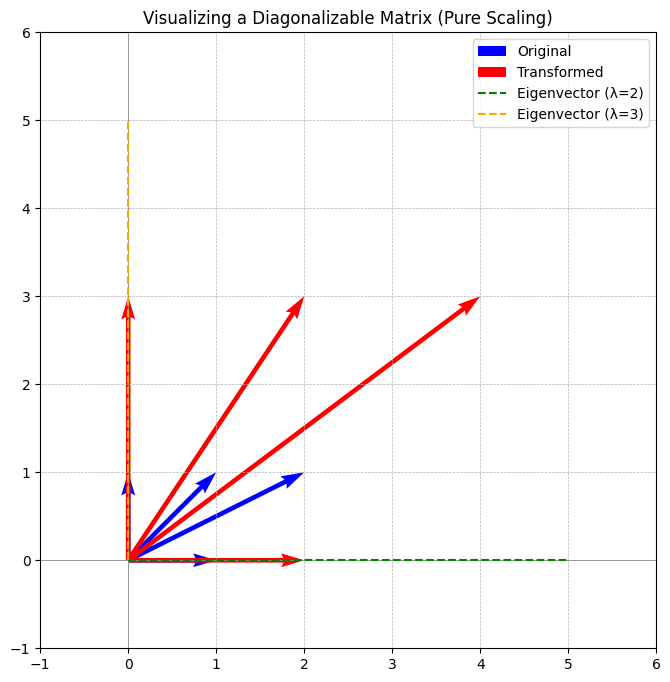

In [6]:
# Define a diagonalizable matrix B
B = np.array([[2, 0],
              [0, 3]])

# Use the same set of vectors as before
vectors = np.array([[1, 0], [0, 1], [1, 1], [2, 1]]).T

# Apply the transformation
transformed_vectors_B = B @ vectors

# Plot setup
fig, ax = plt.subplots(figsize=(8, 8))
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', linewidth=0.5)

# Plot original vectors
for i in range(vectors.shape[1]):
    ax.quiver(0, 0, vectors[0, i], vectors[1, i], angles='xy', scale_units='xy', scale=1, color='blue', label='Original' if i == 0 else "")

# Plot transformed vectors
for i in range(transformed_vectors_B.shape[1]):
    ax.quiver(0, 0, transformed_vectors_B[0, i], transformed_vectors_B[1, i], angles='xy', scale_units='xy', scale=1, color='red', label='Transformed' if i == 0 else "")

# Highlight eigenspaces
ax.plot([0, 5], [0, 0], linestyle='--', color='green', label='Eigenvector (λ=2)')
ax.plot([0, 0], [0, 5], linestyle='--', color='orange', label='Eigenvector (λ=3)')

# Legend and title
ax.legend()
ax.set_title("Visualizing a Diagonalizable Matrix (Pure Scaling)")

plt.show()


In [14]:
S = np.roll(np.eye(5), 3, axis=0)
S

array([[0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft

# Signal length
n = 4

# Construct the shift operator (circulant right shift)
S = np.roll(np.eye(n), 1, axis=1)

# Example convolution kernel (impulse response)
h = np.array([1, 2, 1, 0])
# Construct the circulant convolution matrix for h
H = np.array([np.roll(h, i) for i in range(n)])

# Compute eigenvectors and eigenvalues of S
eigvals_S, eigvecs_S = np.linalg.eig(S)

# Fourier matrix (scaled DFT matrix)
omega = np.exp(-2j * np.pi / n)
F = np.array([[omega**(i * j) for j in range(n)] for i in range(n)]) / np.sqrt(n)

# Check diagonalization
Lambda_S = np.round(np.diag(np.linalg.inv(F) @ S @ F), decimals=4)
Lambda_H = np.round(np.diag(np.linalg.inv(F) @ H @ F), decimals=4)

# Display the results using pandas
import pandas as pd
results = pd.DataFrame({
    "Eigenvalue of Shift (S)": np.round(eigvals_S, 4),
    "DFT-based Diagonal of S": Lambda_S,
    "DFT-based Diagonal of H": Lambda_H,
})

# Display the DataFrame
print("Joint Diagonalization of Convolution and Shift")
print(results)

Joint Diagonalization of Convolution and Shift
   Eigenvalue of Shift (S)  DFT-based Diagonal of S  DFT-based Diagonal of H
0                -1.0+0.0j                 1.0-0.0j                 4.0-0.0j
1                 0.0+1.0j                 0.0-1.0j                 0.0-2.0j
2                 0.0-1.0j                -1.0+0.0j                -0.0+0.0j
3                 1.0+0.0j                 0.0+1.0j                 0.0+2.0j


Graph Signal Filtering via Spectral Graph Theory    Node  Original Signal  Filtered Signal
0     0              0.0          -0.1236
1     1              0.0           0.3236
2     2              1.0           0.6000
3     3              0.0           0.3236
4     4              0.0          -0.1236


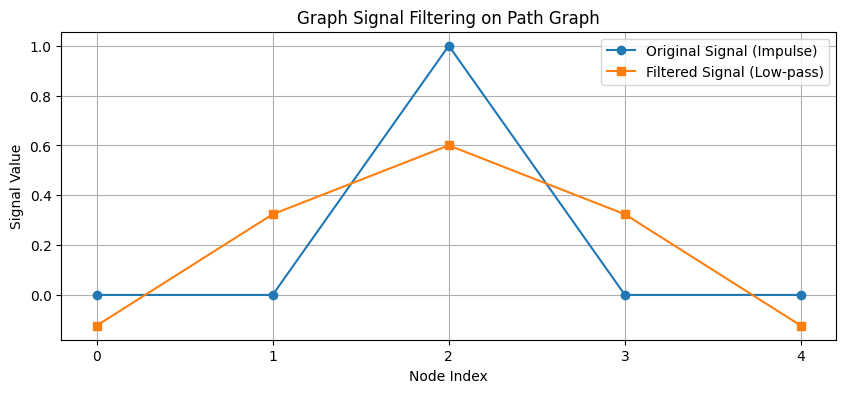

In [22]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Create a simple undirected graph
G = nx.path_graph(5)  # Path graph with 5 nodes

# Compute combinatorial Laplacian
L = nx.laplacian_matrix(G).toarray()

# Compute eigenvalues and eigenvectors of Laplacian
eigvals, eigvecs = np.linalg.eigh(L)

# Create a simple graph signal (e.g., impulse at node 2)
f = np.zeros(5)
f[2] = 1

# Compute Graph Fourier Transform (GFT)
f_hat = eigvecs.T @ f

# Filter in frequency domain: low-pass (suppress high frequencies)
low_pass_filter = np.array([1 if l < 2 else 0 for l in eigvals])
f_hat_filtered = f_hat * low_pass_filter

# Inverse GFT to reconstruct filtered signal
f_filtered = eigvecs @ f_hat_filtered

# Prepare to display all results
import pandas as pd

df = pd.DataFrame({
    "Node": np.arange(5),
    "Original Signal": f,
    "Filtered Signal": np.round(f_filtered, 4)
})

print("Graph Signal Filtering via Spectral Graph Theory", df)

# Plot original and filtered signals
plt.figure(figsize=(10, 4))
plt.plot(f, label="Original Signal (Impulse)", marker='o')
plt.plot(f_filtered, label="Filtered Signal (Low-pass)", marker='s')
plt.xticks(np.arange(5))
plt.xlabel("Node Index")
plt.ylabel("Signal Value")
plt.title("Graph Signal Filtering on Path Graph")
plt.legend()
plt.grid(True)
plt.show()
